In [1]:
from flwr_datasets.partitioner import IidPartitioner
from flwr_datasets import FederatedDataset


partitioner = IidPartitioner(num_partitions=10)
FDS = FederatedDataset(
    dataset="vicgalle/alpaca-gpt4",
    partitioners={"train": partitioner},
)
client_trainset = FDS.load_partition(1, "train")
client_trainset = client_trainset.rename_column("output", "response")
client_trainset

ModuleNotFoundError: No module named 'flwr_datasets'

In [12]:
import datasets
from datasets import load_dataset, DatasetDict
import pandas as pd
from functools import partial
from sklearn.model_selection import train_test_split


def get_dataset(dataset_name, local_data_dir=None):

    if dataset_name in ["gsm8k"]:
        dataset_name = local_data_dir + dataset_name if local_data_dir is not None else dataset_name
        dataset = load_dataset(dataset_name, name="main")
    elif dataset_name in ["lighteval/MATH"]:
        dataset_name = local_data_dir + dataset_name if local_data_dir is not None else dataset_name
        dataset = load_dataset(dataset_name, name="all")
    else:
        dataset_name = local_data_dir + dataset_name if local_data_dir is not None else dataset_name
        dataset = load_dataset(dataset_name)

    return dataset

# Function to split a dataset dictionary into two 50/50 parts
def split_dataset_50_50(dataset_dict):
    split_datasets = {
        'ds_1': None,
        'ds_2': None
    }
    for split in ['train', 'valid', 'test']:
        if split in dataset_dict:
            dataset_split_1, dataset_split_2 = train_test_split(
                dataset_dict[split], test_size=0.5, shuffle=True, seed=42
            )
            print(f">> ===== After split, Dataset1 {split} has {len(dataset_split_1)} examples. =====")
            print(f">> ===== After split, Dataset2 {split} has {len(dataset_split_2)} examples. =====")
            split_datasets['ds_1'][split] = dataset_split_1
            split_datasets['ds_2'][split] = dataset_split_2
    return DatasetDict(split_datasets['ds_1']), DatasetDict(split_datasets['ds_2'])


def process_sft_dataset(dataset_name, dataset, dataset_sample):
    if dataset_name in ["lucasmccabe-lmi/CodeAlpaca-20k", "yahma/alpaca-cleaned", "FinGPT/fingpt-sentiment-train"]:
        dataset = dataset.map(alpaca_format, remove_columns=['input', 'output'], desc=f"Preprocessing {dataset_name} for unified format.")
    elif dataset_name in ["WizardLM/WizardLM_evol_instruct_70k"]:
        dataset = dataset.rename_column("output", "response")
    elif dataset_name in ["tatsu-lab/alpaca", "vicgalle/alpaca-gpt4", "gbharti/finance-alpaca"]:
        dataset = dataset.map(alpaca_format, remove_columns=['input', 'output', 'text'], desc=f"Preprocessing {dataset_name} for unified format.")
    elif dataset_name in ["TIGER-Lab/MathInstruct"]:
        df = pd.DataFrame(dataset)
        df = df.drop_duplicates(subset=['instruction'])
        dataset = datasets.Dataset.from_pandas(df)
        dataset = dataset.rename_column("output", "response")
        dataset = dataset.remove_columns(['source'])
    elif dataset_name in ["lighteval/MATH"]:
        dataset = dataset.rename_column("solution", "response")
        dataset = dataset.rename_column("problem", "instruction")
        dataset = dataset.remove_columns(['level', 'type'])
    elif dataset_name in ['gsm8k']:
        dataset = dataset.rename_column("question", "instruction")
        dataset = dataset.rename_column("answer", "response")
    elif dataset_name in ['medalpaca/medical_meadow_medical_flashcards']:       # TODO: 'lavita/ChatDoctor-HealthCareMagic-100k'. not sure whether to discard the instruction.
        dataset = dataset.remove_columns(['instruction'])
        dataset = dataset.rename_column("input", "instruction")
        dataset = dataset.rename_column("output", "response")
    else:
        raise NotImplementedError(f"Dataset {dataset_name} is not supported.")
    dataset = dataset.shuffle(seed=2023)
    if dataset_sample:
        num_sample = min(len(dataset), dataset_sample)
        dataset = dataset.select(range(num_sample))
    print(f">> ===== After processing, Dataset {dataset_name} has {len(dataset)} examples. =====")
    print(f">> ===== Spliting two parts datasets =====")
    
    if len(dataset['train']) > 10000 and len(dataset['test']) >= 2000:
        dataset = split_dataset_50_50(dataset)
    return dataset

def alpaca_format(example):
    if example['input'] == "":
        example["instruction"] = example["instruction"]
    else:
        example["instruction"] = example["instruction"] + " " + example['input']
    example["response"] = example['output']
    return example




In [25]:
import datasets
import pandas as pd
from datasets import Dataset, DatasetDict, load_dataset
from sklearn.model_selection import train_test_split
from functools import partial


class DatasetAbstract:
    def __init__(self, dataset_name: list[str], category: str):
        self.dataset_name = dataset_name
        self.metadata = {
            'domain': category
        }
    
    def _processing_data(self):
        pass
    
    @classmethod
    def get_dataset(cls, dataset_name, local_data_dir=None):
        if dataset_name in ["gsm8k"]:
            dataset_name = local_data_dir + dataset_name if local_data_dir is not None else dataset_name
            dataset = load_dataset(dataset_name, name="main")
        else:
            dataset_name = local_data_dir + dataset_name if local_data_dir is not None else dataset_name
            dataset = load_dataset(dataset_name)
        
        return dataset
    
    def get_split_dataset(self, dataset):
        print(f">> ===== After processing, Dataset has {len(dataset)} examples. =====")
        if len(dataset) > 10000:
            ds_part1, ds_part2 = train_test_split(
                dataset, test_size=0.5, shuffle=True, random_state=42
            )
            print(f">> ===== After split, Dataset1 has {len(ds_part1)} examples and Dataset2 has {len(ds_part2)} examples. =====")
            list_dataset = []
            for subset in [ds_part1, ds_part2]:
                train, test = train_test_split(
                    subset, test_size=0.2, shuffle=True, random_state=42
                )
                ds = DatasetDict({
                    "train": Dataset.from_pandas(train).remove_columns(['__index_level_0__']),
                    "test": Dataset.from_pandas(test).remove_columns(['__index_level_0__'])
                })
                list_dataset.append(ds)
            return list_dataset
                
        else:
            train, test = train_test_split(
                dataset , test_size=0.2, shuffle=True, random_state=42
            )
            ds = DatasetDict(
                {
                    "train": Dataset.from_pandas(train).remove_columns(['__index_level_0__']),
                    "test": Dataset.from_pandas(test).remove_columns(['__index_level_0__'])
                }
            )
            return [ds]

        
class GeneralDataset(DatasetAbstract):
    
    def __init__(self):
        list_dataset = ["tatsu-lab/alpaca", "vicgalle/alpaca-gpt4"]
        super().__init__(list_dataset, 'general')
        self._processing_data()
    
    def _processing_data(self):
        datasets = []
        for dataset_name in self.dataset_name:
            datasets.append(
                pd.DataFrame(super().get_dataset(dataset_name=dataset_name, local_data_dir=None)['train'])
            )
        dataset = pd.concat(datasets, ignore_index=True)
        self.list_dataset = self.get_split_dataset(dataset)
            
        

class FinanceDataset(DatasetAbstract):
    
    def __init__(self):
        list_dataset = ["gbharti/finance-alpaca", "FinGPT/fingpt-sentiment-train"]
        super().__init__(list_dataset, 'finance')
        
        self._processing_data()
    
    def _processing_data(self):
        datasets = []
        for dataset_name in self.dataset_name:
            ds = super().get_dataset(dataset_name=dataset_name, local_data_dir=None)['train']
            if dataset_name == 'gbharti/finance-alpaca':
                ds = ds.remove_columns(['text'])
            df = pd.DataFrame(ds)
            datasets.append(df)
        dataset = pd.concat(datasets, ignore_index=True)
        self.list_dataset = self.get_split_dataset(dataset)
        

class MathDataset(DatasetAbstract):
    
    def __init__(self):
        list_dataset = ["TIGER-Lab/MathInstruct", "xDAN2099/lighteval-MATH", "gsm8k"]
        super().__init__(list_dataset, 'math')
        self._processing_data()
        
    
    def get_split_dataset(self, dataset):
        dataset_train, dataset_test = dataset[0], dataset[1]
        print(f">> ===== After processing, Dataset  has {len(dataset_train)} examples. =====")
        if len(dataset_train) > 10000:
            ds_train_part1, ds_train_part2 = train_test_split(
                dataset_train, test_size=0.5, shuffle=True, random_state=42
            )
            ds_test_part1, ds_test_part2 = train_test_split(
                dataset_test, test_size=0.5, shuffle=True, random_state=42
            )
            print(f">> ===== After split, Dataset1 has {len(ds_train_part1)} examples and Dataset2 has {len(ds_train_part2)} examples. =====")
            list_dataset = []
            for i in range(2):
                ds = DatasetDict({
                    "train": Dataset.from_pandas(eval(f'ds_train_part{i+1}')).remove_columns(['__index_level_0__']), 
                    "test": Dataset.from_pandas(eval(f'ds_test_part{i+1}')).remove_columns(['__index_level_0__'])
                })
                list_dataset.append(ds)
            return list_dataset
                
        else:
            ds = DatasetDict(
                {
                    "train": Dataset.from_pandas(dataset_train).remove_columns(['__index_level_0__']),
                    "test": Dataset.from_pandas(dataset_test).remove_columns(['__index_level_0__'])
                }
            )
    
    def _processing_data(self):
        datasets_train, datasets_test = [], []
        for dataset_name in self.dataset_name:
            ds_tmp = super().get_dataset(dataset_name=dataset_name, local_data_dir=None)
            if dataset_name == 'TIGER-Lab/MathInstruct':
                df = pd.DataFrame(ds_tmp['train'])
                df = df.drop_duplicates(subset=['instruction'])
                df = df.drop(['source'], axis=1)
                df_train, df_test = train_test_split(df, test_size=0.3, shuffle=True, random_state=42)
                
            elif dataset_name == "xDAN2099/lighteval-MATH":
                ds_tmp = ds_tmp.remove_columns(['level', 'type'])
                ds_tmp = ds_tmp.rename_column("solution", "output")
                ds_tmp = ds_tmp.rename_column("problem", "instruction")
                df_train, df_test = pd.DataFrame(ds_tmp['train']), pd.DataFrame(ds_tmp['test'])
            
            elif dataset_name == 'gsm8k':
                ds_tmp = ds_tmp.rename_column("answer", "output")
                ds_tmp = ds_tmp.rename_column("question", "instruction")
                df_train, df_test = pd.DataFrame(ds_tmp['train']), pd.DataFrame(ds_tmp['test'])
            
            df_train['input'] = [''] * len(df_train)
            df_test['input'] = [''] * len(df_test)
            datasets_train.append(df_train)
            datasets_test.append(df_test)
            
        dataset_train = pd.concat(datasets_train, ignore_index=True)
        dataset_test = pd.concat(datasets_test, ignore_index=True)
        dataset = [dataset_train, dataset_test]
        self.list_dataset = self.get_split_dataset(dataset)
    

class MedicalDataset(DatasetAbstract):
    
    def __init__(self):
        list_dataset = ["medalpaca/medical_meadow_medical_flashcards"]
        super().__init__(list_dataset, 'medical')
        self._processing_data()
    
    def _processing_data(self):
        datasets = []
        for dataset_name in self.dataset_name:
            ds = super().get_dataset(dataset_name=dataset_name, local_data_dir=None)['train']
            if dataset_name == 'medalpaca/medical_meadow_medical_flashcards':
                ds = ds.remove_columns(['instruction'])
                ds = ds.rename_column("input", "instruction")
            
            df = pd.DataFrame(ds)
            df['input'] = [''] * len(df)
            datasets.append(df)
        dataset = pd.concat(datasets, ignore_index=True)
        self.list_dataset = self.get_split_dataset(dataset)
        
class CodeDataset(DatasetAbstract):
    
    def __init__(self):
        list_dataset = ["lucasmccabe-lmi/CodeAlpaca-20k", "WizardLMTeam/WizardLM_evol_instruct_70k"]
        super().__init__(list_dataset, 'code')
        self._processing_data()
    
    def _processing_data(self):
        datasets = []
        for dataset_name in self.dataset_name:
            ds = super().get_dataset(dataset_name=dataset_name, local_data_dir=None)['train']
            df = pd.DataFrame(ds)
            if dataset_name == 'WizardLMTeam/WizardLM_evol_instruct_70k':
                df['input'] = [''] * len(df)
            datasets.append(df)
        dataset = pd.concat(datasets, ignore_index=True)
        self.list_dataset = self.get_split_dataset(dataset)
        
client_id_dataset = {
    '1': GeneralDataset().list_dataset[0],
    '2': GeneralDataset().list_dataset[1],
    '3': FinanceDataset().list_dataset[0],
    '4': FinanceDataset().list_dataset[1],
    '5': MathDataset().list_dataset[0],
    '6': MathDataset().list_dataset[1],
    '7': MedicalDataset().list_dataset[0],
    '8': MedicalDataset().list_dataset[1],
    '9': CodeDataset().list_dataset[0],
    '10': CodeDataset().list_dataset[1],
}

In [27]:
FinanceDataset().list_dataset

README.md:   0%|          | 0.00/709 [00:00<?, ?B/s]

Cleaned_date.json:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68912 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/529 [00:00<?, ?B/s]

(…)-00000-of-00001-dabab110260ac909.parquet:   0%|          | 0.00/6.42M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/76772 [00:00<?, ? examples/s]

>> ===== After processing, Dataset has 145684 examples. =====
>> ===== After split, Dataset1 has 72842 examples and Dataset2 has 72842 examples. =====


[DatasetDict({
     train: Dataset({
         features: ['instruction', 'input', 'output'],
         num_rows: 58273
     })
     test: Dataset({
         features: ['instruction', 'input', 'output'],
         num_rows: 14569
     })
 }),
 DatasetDict({
     train: Dataset({
         features: ['instruction', 'input', 'output'],
         num_rows: 58273
     })
     test: Dataset({
         features: ['instruction', 'input', 'output'],
         num_rows: 14569
     })
 })]

In [24]:
client_id_dataset = {
    '1':
}

,letter,number
0,a,1
1,b,2


In [25]:
import pandas as pd
df1 = pd.DataFrame([['a', 1], ['b', 2]],
                   columns=['letter', 'number'])

df2 = pd.DataFrame([['c', 3], ['d', 4]],
                   columns=['letter', 'number'])

df3 = pd.DataFrame([['e', 5], ['f', 6]],
                   columns=['letter', 'number'])

pd.concat([df1], ignore_index=True)

,letter,number
0,a,1
1,b,2


In [19]:
dataset = get_dataset(dataset_name="gsm8k", local_data_dir=None)
datasets = process_sft_dataset(dataset_name="gsm8k", dataset=dataset, dataset_sample=None)
datasets = datasets.rename_column("response", "output")
datasets

>> ===== After processing, Dataset gsm8k has 2 examples. =====
>> ===== Spliting two parts datasets =====


DatasetDict({
    train: Dataset({
        features: ['instruction', 'output'],
        num_rows: 7473
    })
    test: Dataset({
        features: ['instruction', 'output'],
        num_rows: 1319
    })
})

In [18]:
def clean_llm_text(text):
    """
    Clean and normalize text from LLM outputs by removing noise and repetitions.
    
    Args:
        text (str): Raw text from LLM prediction
        
    Returns:
        str: Cleaned and normalized text
    """
    import re
    
    # Remove repetitive patterns (like 'cor cor cor' or 'asesases')
    def remove_repetitions(text):
        # Split into words
        words = text.split()
        cleaned_words = []
        prev_word = None
        repetition_count = 0
        
        for word in words:
            if word == prev_word:
                repetition_count += 1
                if repetition_count < 2:  # Allow up to 2 repetitions for legitimate cases
                    cleaned_words.append(word)
            else:
                repetition_count = 0
                cleaned_words.append(word)
            prev_word = word
            
        return ' '.join(cleaned_words)
    
    def remove_repeats(text):
        # Remove repeated words
        pattern_words = r'\b(\w+)(?:\s+\1\b)+'
        text = re.sub(pattern_words, r'\1', text)

        # Remove repeated character patterns (like 'asasas')
        pattern_chars = r'(\w+?)\1+'
        text = re.sub(pattern_chars, r'\1', text)

        return text
    
    # Remove excessive punctuation
    def normalize_punctuation(text):
        # Replace multiple exclamation/question marks with single ones
        text = re.sub(r'!+', '!', text)
        text = re.sub(r'\?+', '?', text)
        # Remove multiple periods (except for ellipsis)
        text = re.sub(r'\.{4,}', '...', text)
        text = text.replace('cor', '').replace('asesa', '')
        return text
    
    # Main cleaning pipeline
    cleaned_text = text.strip()
    
    # Remove common noise patterns
    noise_patterns = [
        r'\n+',              # Multiple newlines
        r'\s+',              # Multiple spaces
        r'\\n',              # Literal \n
        r'\\t',              # Literal \t
    ]
    
    for pattern in noise_patterns:
        cleaned_text = re.sub(pattern, ' ', cleaned_text)
    
    # Apply cleaning functions
    # cleaned_text = remove_repetitions(cleaned_text)
    cleaned_text = remove_repeats(cleaned_text)
    cleaned_text = normalize_punctuation(cleaned_text)
    cleaned_text = ' '.join(cleaned_text.split())  # Normalize spacing
    
    return cleaned_text

In [20]:
text_str = f"""at\n\nSea Animals: Whale, Fish cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor', " cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor One example of a technology that uses artificial intelligence is a virtual personal assistant such as Amazon's Alexa, Apple's Siri, or Google Assistant. These devices use natural language processing and machine learning to understand and respond to user's voice commands, providing assistance in tasks such as setting reminders, playing music, or answering questions. cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor cor"""
text_str1 = f"""following into their based mammals animals, water animals.\n\n1 Response:\n \n animals: \n, Elephant,Sea Animals: Dolphin, Dolphin\n\nasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesasesa"""
clean_llm_text(text_str1)

'folowing into their based mamals animals, water animals. 1 Response: animals: , Elephant,Sea Animals: Dolphin, Dolphin'

In [10]:
import torch

x = torch.tensor([1, 2, 3])
torch.unsqueeze(x,dim=0)

tensor([[1, 2, 3]])

In [4]:
%cd /notebooks/template_FL/src/fedllm

/notebooks/template_FL/src/fedllm


In [1]:
from data_domains import data_domain
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize
import json
import pandas as pd

# Download NLTK data if not already downloaded
nltk.download('punkt')

# Load your Alpaca dataset (assuming it's in JSON format)
def load_data(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return pd.DataFrame(data)

# Visualize sequence length distribution
def plot_sequence_length_distribution(df, column_name):
    sequence_lengths = df[column_name].apply(lambda x: len(word_tokenize(x)))
    
    plt.figure(figsize=(10, 6))
    sns.histplot(sequence_lengths, bins=50, kde=False)
    plt.title(f'Sequence Length Distribution ({column_name})')
    plt.xlabel('Sequence Length')
    plt.ylabel('Frequency')
    plt.show()

# Generate and visualize a word cloud
def generate_word_cloud(text_series):
    all_text = ' '.join(text_series.tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud')
    plt.show()


# file_path = 'alpaca_data.json'  # Replace with your actual file path
# df = load_data(file_path)

# # Example columns: 'instruction', 'input', 'output'
# for column in ['instruction', 'input', 'output']:
#     print(f"Analyzing {column}...")
#     plot_sequence_length_distribution(df, column)
#     generate_word_cloud(df[column])

>> ===== After processing, Dataset has 104004 examples. =====
>> ===== After split, Dataset1 has 52002 examples and Dataset2 has 52002 examples. =====
>> ===== After processing, Dataset has 145684 examples. =====
>> ===== After split, Dataset1 has 72842 examples and Dataset2 has 72842 examples. =====
>> ===== After processing, Dataset  has 172169 examples. =====
>> ===== After split, Dataset1 has 86084 examples and Dataset2 has 86085 examples. =====
>> ===== After processing, Dataset has 33955 examples. =====
>> ===== After split, Dataset1 has 16977 examples and Dataset2 has 16978 examples. =====
>> ===== After processing, Dataset has 90022 examples. =====
>> ===== After split, Dataset1 has 45011 examples and Dataset2 has 45011 examples. =====


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
data_domain

{'general': [DatasetDict({
      train: Dataset({
          features: ['instruction', 'input', 'output', 'text'],
          num_rows: 41601
      })
      test: Dataset({
          features: ['instruction', 'input', 'output', 'text'],
          num_rows: 9360
      })
  }),
  DatasetDict({
      train: Dataset({
          features: ['instruction', 'input', 'output', 'text'],
          num_rows: 41601
      })
      test: Dataset({
          features: ['instruction', 'input', 'output', 'text'],
          num_rows: 9360
      })
  })],
 'finance': [DatasetDict({
      train: Dataset({
          features: ['instruction', 'input', 'output'],
          num_rows: 58273
      })
      test: Dataset({
          features: ['instruction', 'input', 'output'],
          num_rows: 13112
      })
  }),
  DatasetDict({
      train: Dataset({
          features: ['instruction', 'input', 'output'],
          num_rows: 58273
      })
      test: Dataset({
          features: ['instruction', 'input', 'ou

In [13]:
import pandas as pd
from datasets import Dataset, DatasetDict, load_dataset

data_vis = {}

for k, v in data_domain.items():
    ds = []
    for data in v:
        ds.append(pd.DataFrame(data['train']))
    data_vis[k] = pd.concat(ds, ignore_index=True)

In [16]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Figure saved to /notebooks/template_FL/src/fedllm/sequence_length_distribution.png


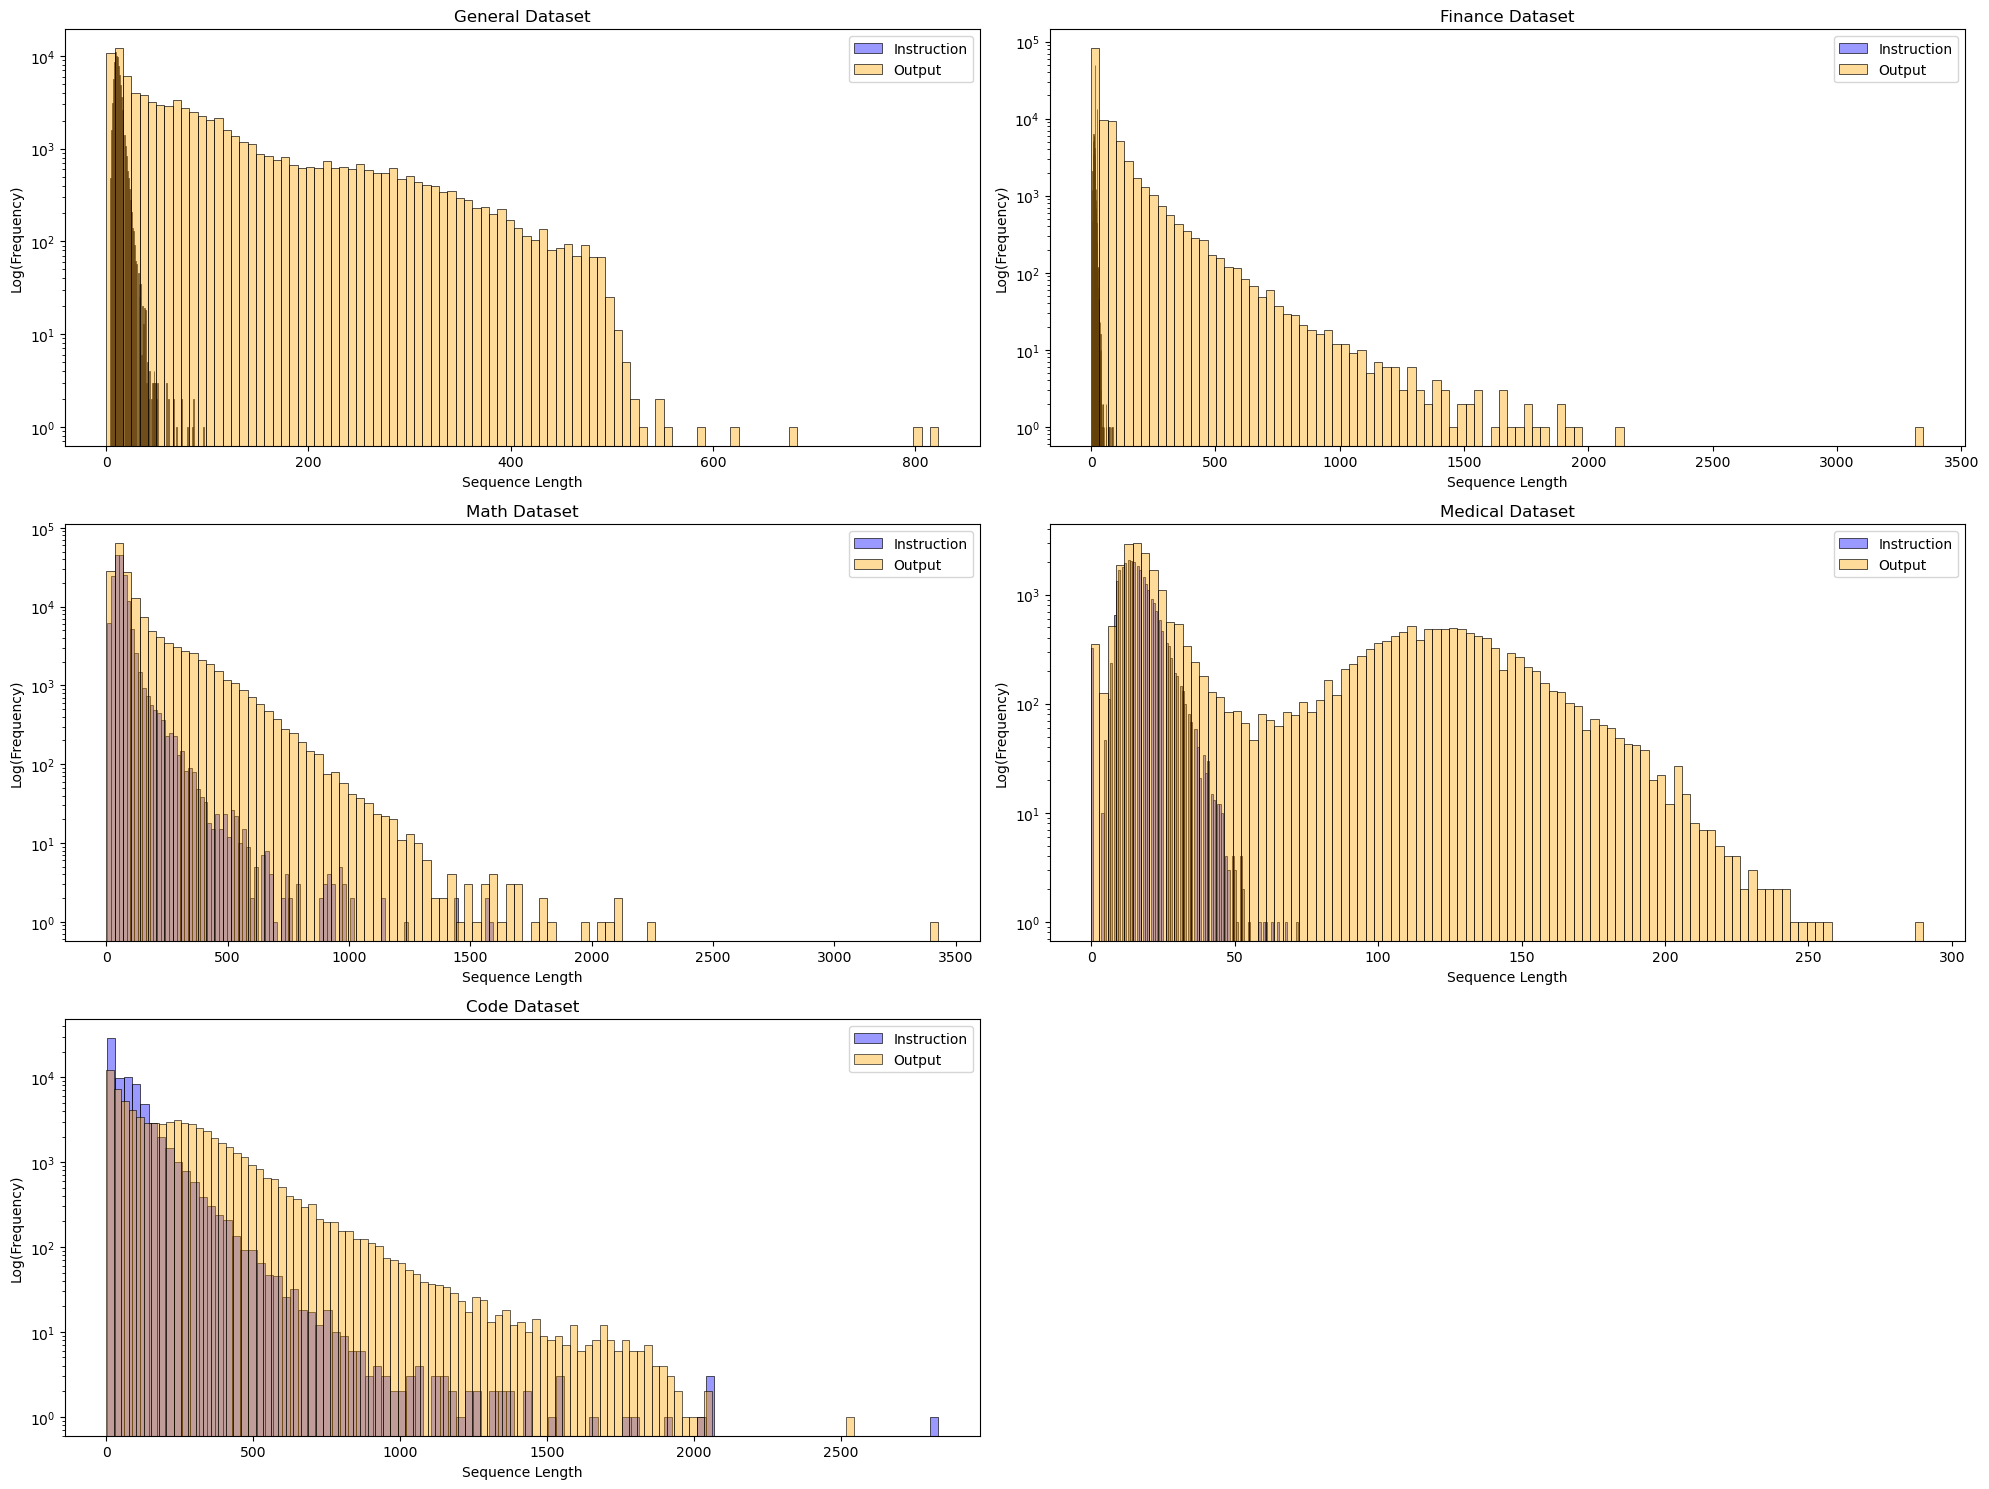

In [21]:
def get_sequence_lengths(df, column_name):
    return df[column_name].apply(lambda x: len(word_tokenize(str(x))))

# Create subplots in a 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(20, 15))

# Flatten the axes array for easier indexing
axes = axes.flatten()

for idx, (dataset_name, df) in enumerate(data_vis.items()):

    instruction_lengths = get_sequence_lengths(df, 'instruction')
    output_lengths = get_sequence_lengths(df, 'output')

    # Plot sequence length distributions on the same subplot
    sns.histplot(instruction_lengths, bins=100, kde=False, ax=axes[idx], label='Instruction', color='blue', alpha=0.4)
    sns.histplot(output_lengths, bins=100, kde=False, ax=axes[idx], label='Output', color='orange', alpha=0.4)

    axes[idx].set_title(f'{dataset_name.capitalize()} Dataset')
    axes[idx].set_xlabel('Sequence Length')
    axes[idx].set_ylabel('Log(Frequency)')
    axes[idx].legend()
    
    # Set y-axis to log scale
    axes[idx].set_yscale('log')

# Hide the last empty subplot if there are fewer than 6 datasets
if len(data_vis) < 6:
    fig.delaxes(axes[-1])

plt.tight_layout()

# Save the figure to a PNG file
output_file = '/notebooks/template_FL/src/fedllm/sequence_length_distribution.png'
plt.savefig(output_file, dpi=600, bbox_inches='tight')
print(f"Figure saved to {output_file}")
plt.show()

Figure saved to /notebooks/template_FL/src/fedllm/wordclouds_5_tasks_insstruction&output.png


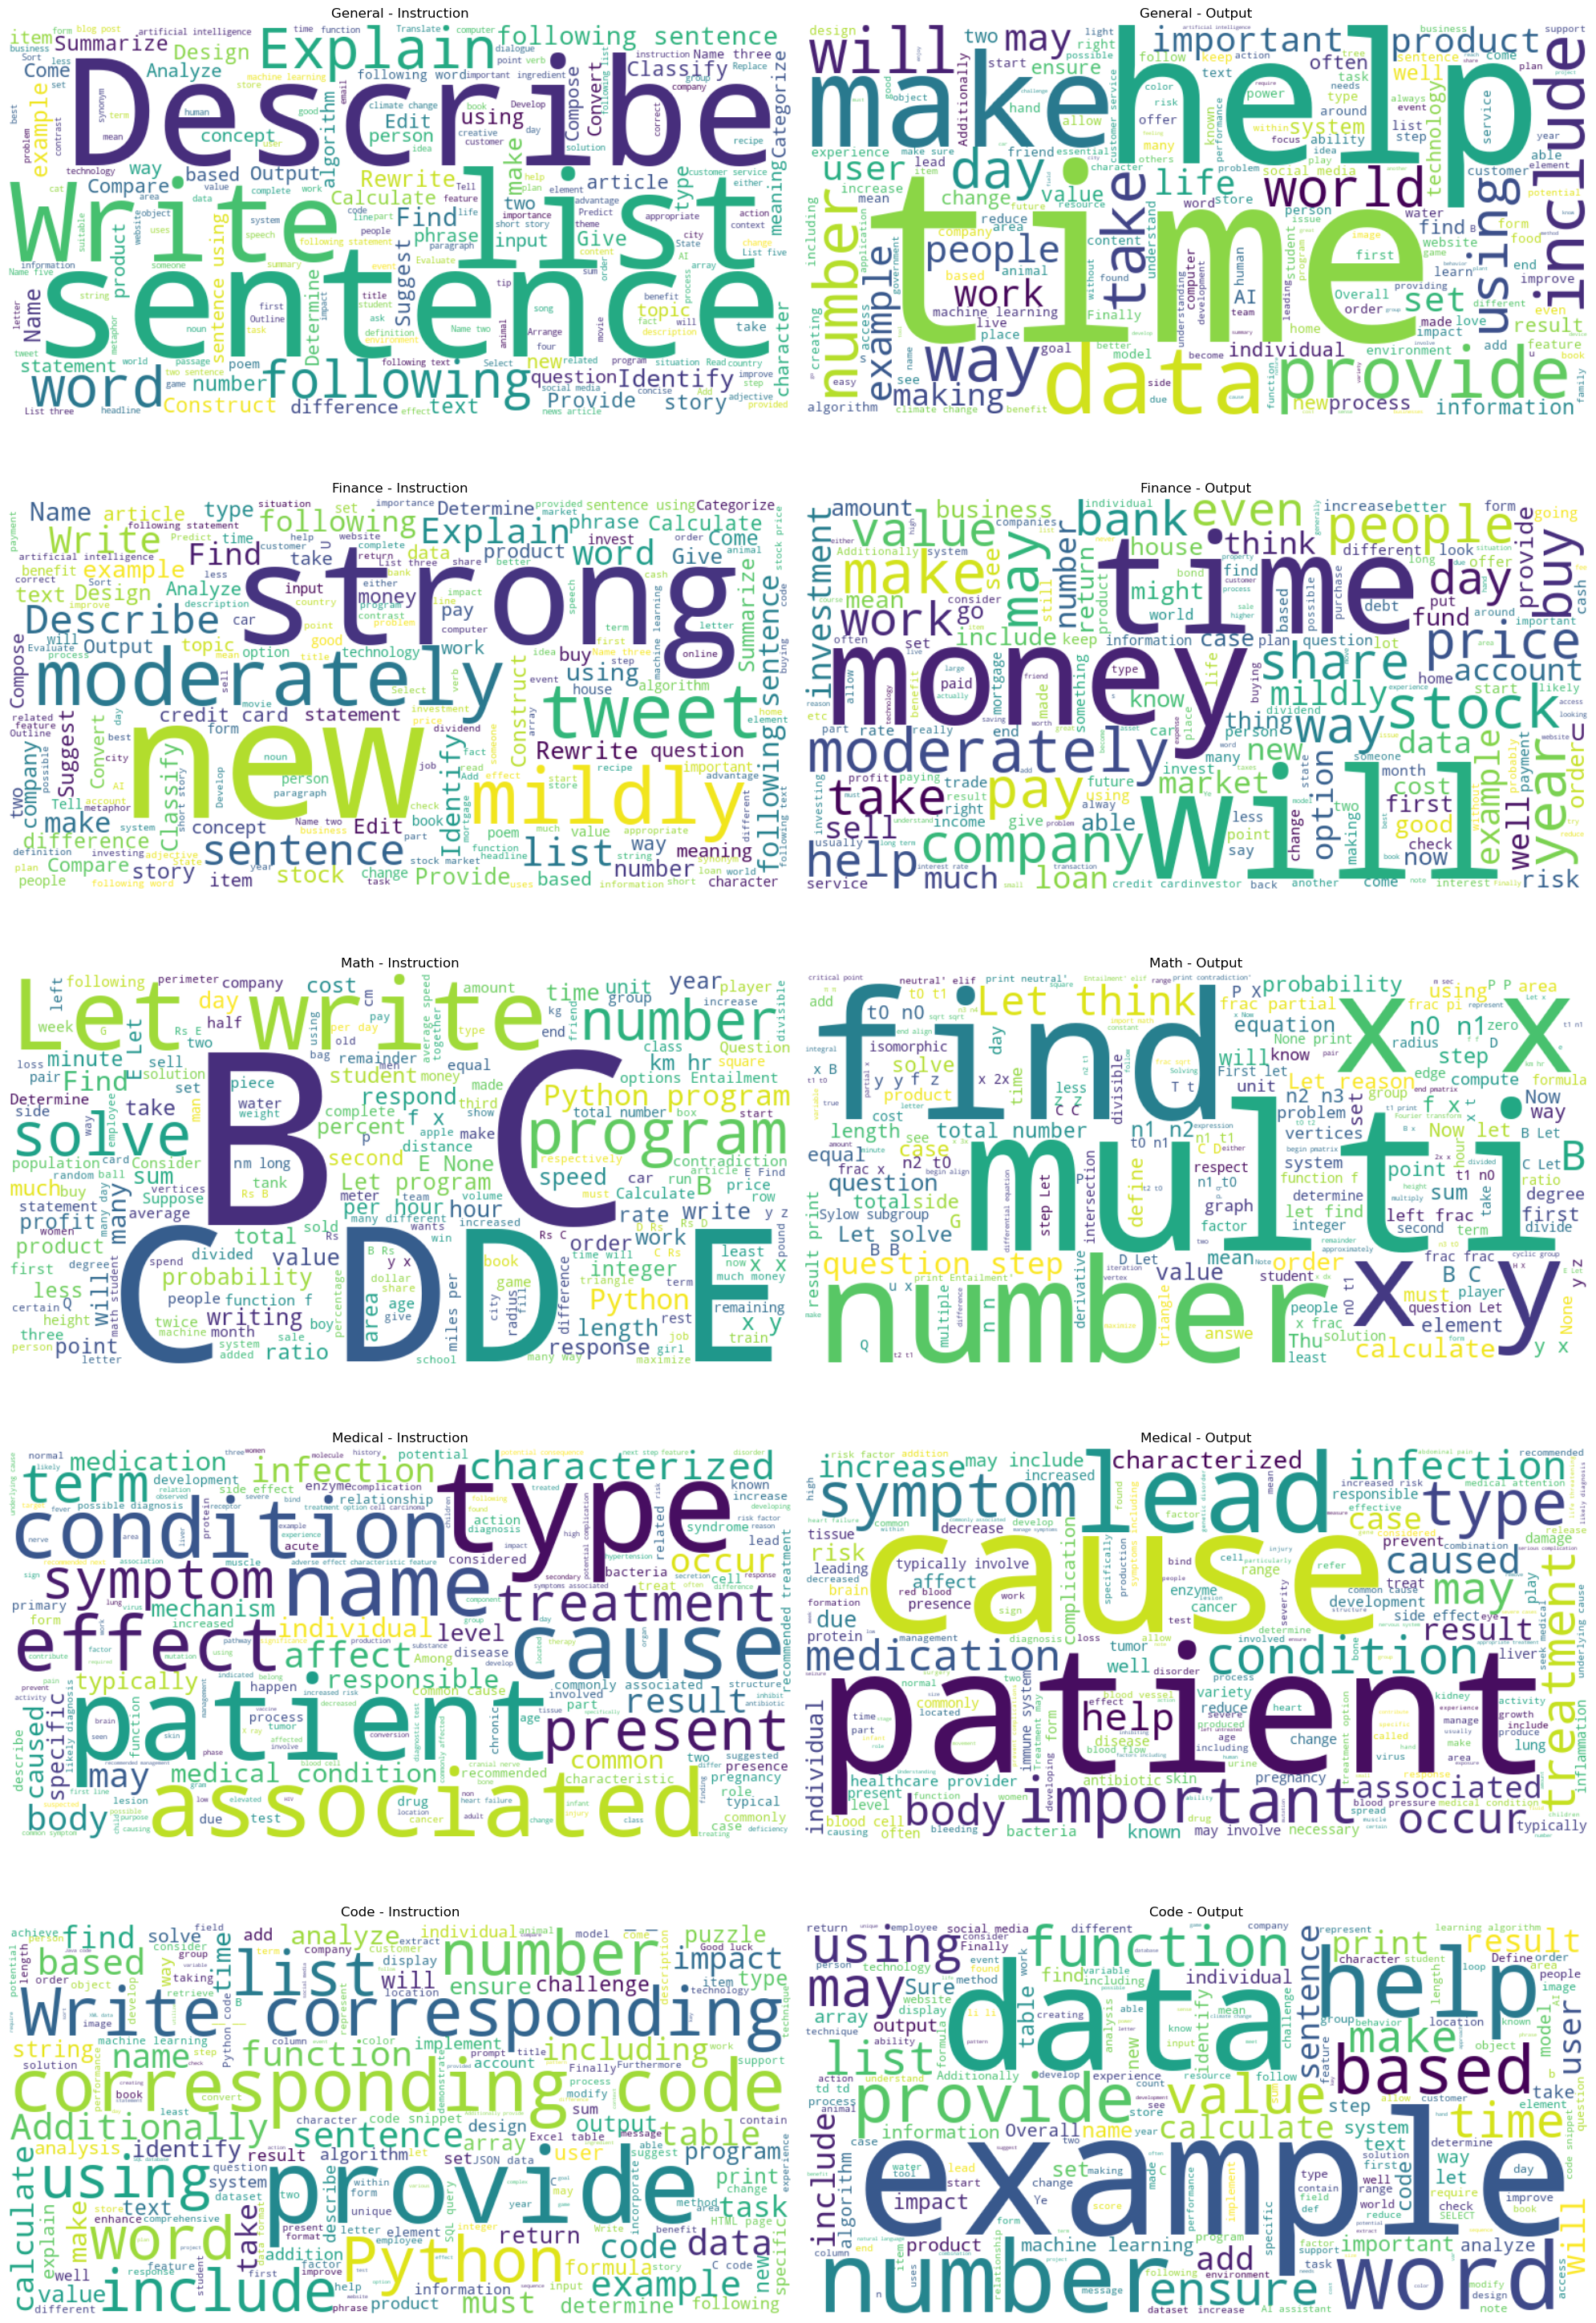

In [30]:
from wordcloud import WordCloud, STOPWORDS


# Generate word cloud from text series
def generate_word_cloud(text_series, ax):
    stopwords = set(STOPWORDS)
    more_stopwords = {'one', 'br', 'Po', 'th', 'sayi', 
                      'fo', 'Unknown' ,'generate', 'sentiment', 
                      'positive', 'negative', 'neutral',
                      'answer', 'please', 'choice', 'choices', 'choose', 'create', 'given', 'use', 'used',
                      'need', 'want', 'wanting',
                      
    }
    stopwords = stopwords.union(more_stopwords)
    
    all_text = ' '.join(text_series.dropna().astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords = stopwords).generate(all_text)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    
# Create subplots in a 5x2 grid
fig, axes = plt.subplots(5, 2, figsize=(20, 30))

for idx, (dataset_name, df) in enumerate(data_vis.items()):

    # Generate word cloud for 'instruction' column
    generate_word_cloud(df['instruction'], axes[idx, 0])
    axes[idx, 0].set_title(f'{dataset_name.capitalize()} - Instruction')

    # Generate word cloud for 'output' column
    generate_word_cloud(df['output'], axes[idx, 1])
    axes[idx, 1].set_title(f'{dataset_name.capitalize()} - Output')

plt.tight_layout()

# Save the figure to a PNG file
output_file = '/notebooks/template_FL/src/fedllm/wordclouds_5_tasks_insstruction&output.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"Figure saved to {output_file}")

# Optionally, display the plot
plt.show()

In [3]:
from data_domains import global_test_set_hete
global_test_set_hete

{'general': Dataset({
     features: ['instruction', 'input', 'output', 'text'],
     num_rows: 2082
 }),
 'finance': Dataset({
     features: ['instruction', 'input', 'output'],
     num_rows: 2914
 }),
 'math': Dataset({
     features: ['output', 'instruction', 'input', '__index_level_0__'],
     num_rows: 14738
 }),
 'medical': Dataset({
     features: ['instruction', 'output', 'input'],
     num_rows: 680
 }),
 'code': Dataset({
     features: ['instruction', 'input', 'output'],
     num_rows: 1802
 })}